In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows and columns:
(891, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


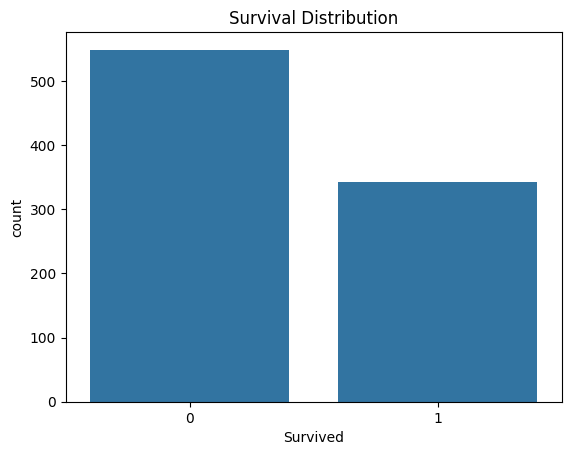

In [6]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Distribution")
plt.show()

In [7]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [8]:
df["IsAlone"] = 0
df.loc[df["FamilySize"] == 1, "IsAlone"] = 1

In [9]:
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

df["Title"].value_counts().head(10)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_509/3654635604.py:1: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [10]:
df["Title"] = df["Title"].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'],
    'Rare'
)

df["Title"] = df["Title"].replace(['Mlle', 'Ms'], 'Miss')
df["Title"] = df["Title"].replace('Mme', 'Mrs')

In [11]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title"
]

X = df[features]
y = df["Survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (891, 10)
Target shape: (891,)


In [12]:
X["Age"] = X["Age"].fillna(X["Age"].median())

/tmp/ipykernel_509/2770350965.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"] = X["Age"].fillna(X["Age"].median())


In [13]:
X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])

/tmp/ipykernel_509/3852755228.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])


In [14]:
print(X.isnull().sum())

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
Title         0
dtype: int64


In [15]:
X = pd.get_dummies(X, columns=["Sex", "Embarked", "Title"], drop_first=True)

print(X.head())
print("New feature shape:", X.shape)

   Pclass   Age  SibSp  Parch     Fare  FamilySize  IsAlone  Sex_male  \
0       3  22.0      1      0   7.2500           2        0      True   
1       1  38.0      1      0  71.2833           2        0     False   
2       3  26.0      0      0   7.9250           1        1     False   
3       1  35.0      1      0  53.1000           2        0     False   
4       3  35.0      0      0   8.0500           1        1      True   

   Embarked_Q  Embarked_S  Title_Miss  Title_Mr  Title_Mrs  Title_Rare  
0       False        True       False      True      False       False  
1       False       False       False     False       True       False  
2       False        True        True     False      False       False  
3       False        True       False     False       True       False  
4       False        True       False      True      False       False  
New feature shape: (891, 14)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 14)
Testing data: (179, 14)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [23]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[0 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [24]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8547486033519553


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



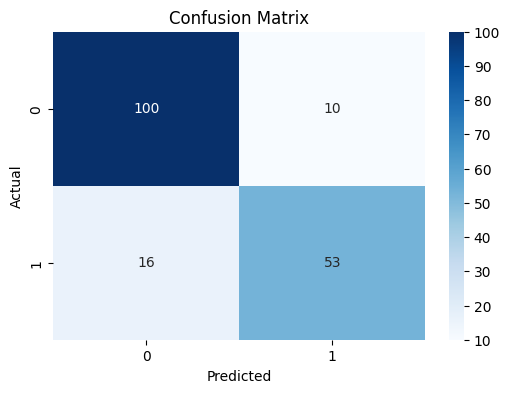

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean Cross-validation Accuracy:")
print(cv_scores.mean())

Cross-validation scores:
[0.77622378 0.81118881 0.83802817 0.83098592 0.83098592]

Mean Cross-validation Accuracy:
0.8174825174825175


In [28]:
train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Cross-validation Mean Accuracy:", cv_scores.mean())

Training Accuracy: 0.8286516853932584
Testing Accuracy: 0.8547486033519553
Cross-validation Mean Accuracy: 0.8174825174825175


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8212290502793296


In [30]:
rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV Scores:", rf_cv_scores)
print("Random Forest Mean CV Accuracy:", rf_cv_scores.mean())

Random Forest CV Scores: [0.77622378 0.73426573 0.83098592 0.85915493 0.79577465]
Random Forest Mean CV Accuracy: 0.7992810006894514


In [31]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Fare          0.242041
Age           0.211451
Title_Mr      0.135107
Sex_male      0.109335
Pclass        0.079186
FamilySize    0.047455
Title_Miss    0.041290
Title_Mrs     0.032591
SibSp         0.029997
Parch         0.022855
Embarked_S    0.020199
IsAlone       0.011133
Embarked_Q    0.008965
Title_Rare    0.008397
dtype: float64


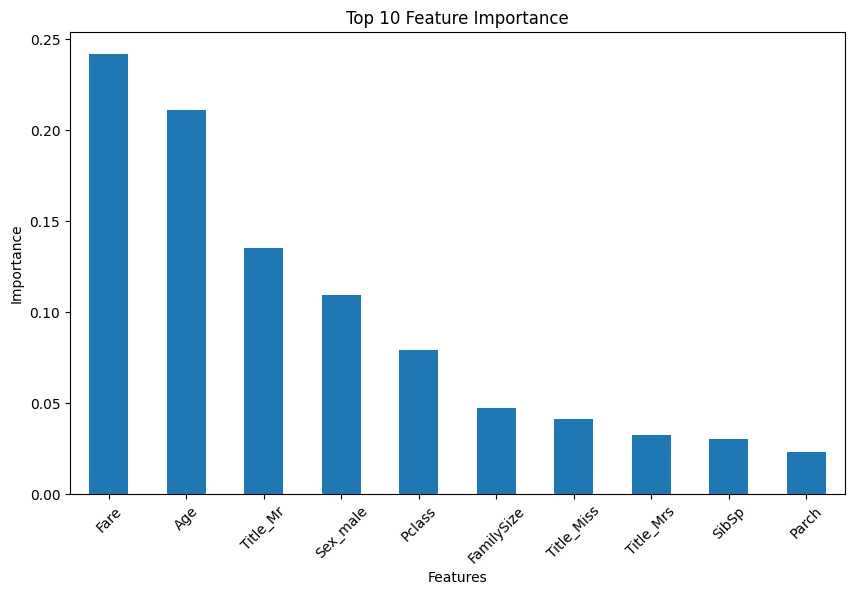

In [32]:
plt.figure(figsize=(10, 6))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [33]:
sample = X_test.iloc[[0]]

prediction = rf_model.predict(sample)

print("Predicted Survival:", prediction[0])

Predicted Survival: 0


In [34]:
if prediction[0] == 1:
    print("Prediction: Passenger is likely to survive.")
else:
    print("Prediction: Passenger is likely not to survive.")

Prediction: Passenger is likely not to survive.
